In [1]:
import pandas as pd

voip = pd.read_csv("E:/Academic/Wireshark Room LAN/Flow/flows_VOIP_raw.csv")
voip["class"] = "VOIP"

web = pd.read_csv("E:/Academic/Wireshark Room LAN/Flow/flows_web_raw.csv")
web["class"] = "WEB"

mail = pd.read_csv("E:/Academic/Wireshark Room LAN/Flow/flows_mail_raw.csv")
mail["class"] = "MAIL"

bulk = pd.read_csv("E:/Academic/Wireshark Room LAN/Flow/flows_Bulk_raw.csv")
bulk["class"] = "BULK"

stream = pd.read_csv("E:/Academic/Wireshark Room LAN/Flow/flows_Streaming_raw.csv")
stream["class"] = "STREAM"

df = pd.concat([voip, web, mail, bulk, stream],
               ignore_index=True)


In [4]:
df.tail()

,flow_id,protocol,src_ip,src_port,dst_ip,dst_port,start_time,end_time,duration,packet_count,byte_count,class
912,110,UDP,142.251.221.238,443,192.168.31.155,61573,1.770386e+09,1.770386e+09,7.733620,13,4709,STREAM
913,111,UDP,142.251.220.67,443,192.168.31.155,57421,1.770386e+09,1.770386e+09,0.113738,20,9106,STREAM
914,112,TCP,192.168.137.53,7680,192.168.31.155,60305,1.770386e+09,1.770386e+09,3.014068,3,198,STREAM
915,113,UDP,103.214.129.249,443,192.168.31.155,54432,1.770386e+09,1.770386e+09,3.479266,4279,4794379,STREAM
916,114,TCP,172.24.67.6,7680,192.168.31.155,60306,1.770386e+09,1.770386e+09,1.011807,2,132,STREAM


In [5]:
df.to_csv("5_labeled.csv", index=False)

In [4]:
import pandas as pd

In [5]:
data = pd.read_csv("5_labeled.csv")

In [6]:
data = data[[
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol",
    "class"
]]

In [7]:
#Convert IP Address → Integer
import ipaddress

data["src_ip"] = data["src_ip"].apply(
    lambda x: int(ipaddress.IPv4Address(x)))

data["dst_ip"] = data["dst_ip"].apply(
    lambda x: int(ipaddress.IPv4Address(x)))

In [8]:
data['protocol'].unique()

array(['TCP', 'UDP'], dtype=object)

In [9]:
proto_map = {"TCP":6, "UDP":17}
data["protocol"] = data["protocol"].map(proto_map)

In [10]:
class_map = {
    "VOIP":0,
    "WEB":1,
    "MAIL":2,
    "BULK":3,
    "STREAM":4
}

data["class_id"] = data["class"].map(class_map)

In [11]:
print(data.dtypes)

src_ip       int64
dst_ip       int64
src_port     int64
dst_port     int64
protocol     int64
class       object
class_id     int64
dtype: object


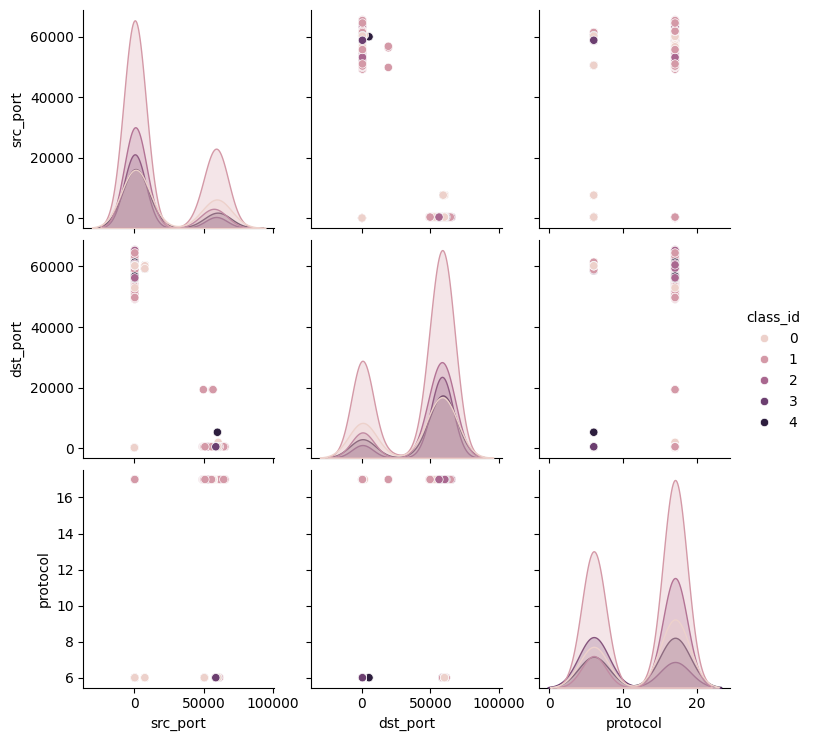

In [12]:
import seaborn as sns

sns.pairplot(data.sample(916),
             hue="class_id",
             vars=["src_port","dst_port","protocol"])

In [13]:
#Generate Classification Rules
from sklearn.tree import DecisionTreeClassifier

X = data[[
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol"
]]

y = data["class_id"]

tree = DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50)

tree.fit(X, y)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=50)

In [15]:
n_rules = tree.get_n_leaves()
print("Rules:", n_rules)

Rules: 15


In [16]:
#Rule Extraction
from sklearn.tree import _tree

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            recurse(tree_.children_left[node],
                    conditions + [(name, "<=", threshold)])

            recurse(tree_.children_right[node],
                    conditions + [(name, ">", threshold)])
        else:
            value = tree_.value[node]
            class_id = value.argmax()
            rules.append((conditions, class_id))

    recurse(0, [])
    return rules


rules = extract_rules(tree,
        ["src_ip","dst_ip","src_port","dst_port","protocol"])

print(len(rules))

15


In [17]:
rules

[([('src_ip', '<=', np.float64(1746230784.0)),
   ('dst_port', '<=', np.float64(58789.0))],
  np.int64(3)),
 ([('src_ip', '<=', np.float64(1746230784.0)),
   ('dst_port', '>', np.float64(58789.0))],
  np.int64(1)),
 ([('src_ip', '>', np.float64(1746230784.0)),
   ('src_port', '<=', np.float64(60806.0)),
   ('src_port', '<=', np.float64(59758.0)),
   ('dst_port', '<=', np.float64(59007.0)),
   ('protocol', '<=', np.float64(11.5)),
   ('dst_port', '<=', np.float64(58738.0))],
  np.int64(1)),
 ([('src_ip', '>', np.float64(1746230784.0)),
   ('src_port', '<=', np.float64(60806.0)),
   ('src_port', '<=', np.float64(59758.0)),
   ('dst_port', '<=', np.float64(59007.0)),
   ('protocol', '<=', np.float64(11.5)),
   ('dst_port', '>', np.float64(58738.0))],
  np.int64(1)),
 ([('src_ip', '>', np.float64(1746230784.0)),
   ('src_port', '<=', np.float64(60806.0)),
   ('src_port', '<=', np.float64(59758.0)),
   ('dst_port', '<=', np.float64(59007.0)),
   ('protocol', '>', np.float64(11.5)),
   ('src

In [18]:
#Convert Tree Rules → Range Rules
import numpy as np
import pandas as pd

features = ["src_ip","dst_ip","src_port","dst_port","protocol"]

# hardware limits
limits = {
    "src_ip": (0, 2**32-1),
    "dst_ip": (0, 2**32-1),
    "src_port": (0, 65535),
    "dst_port": (0, 65535),
    "protocol": (0, 255)
}

def rules_to_ranges(rules):

    rule_table = []

    for rid, (conds, class_id) in enumerate(rules):

        # start with full range
        ranges = {f:list(limits[f]) for f in features}

        # shrink ranges using conditions
        for (feat, op, thr) in conds:

            thr = int(thr)

            if op == "<=":
                ranges[feat][1] = min(ranges[feat][1], thr)
            else:
                ranges[feat][0] = max(ranges[feat][0], thr+1)

        rule_table.append({
            "Rule": rid,
            "src_ip_range": ranges["src_ip"],
            "dst_ip_range": ranges["dst_ip"],
            "src_port_range": ranges["src_port"],
            "dst_port_range": ranges["dst_port"],
            "protocol_range": ranges["protocol"],
            "class_id": class_id
        })

    return pd.DataFrame(rule_table)


rule_df = rules_to_ranges(rules)

print(rule_df)


    Rule              src_ip_range     dst_ip_range  src_port_range  \
0      0           [0, 1746230784]  [0, 4294967295]      [0, 65535]   
1      1           [0, 1746230784]  [0, 4294967295]      [0, 65535]   
2      2  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
3      3  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
4      4  [1746230785, 2398792320]  [0, 4294967295]      [0, 59758]   
5      5  [2398792321, 2398821376]  [0, 4294967295]      [0, 59758]   
6      6  [2398821377, 2398870784]  [0, 4294967295]      [0, 59758]   
7      7  [2398870785, 4294967295]  [0, 4294967295]      [0, 59758]   
8      8  [2398870785, 4294967295]  [0, 4294967295]      [0, 59758]   
9      9  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
10    10  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
11    11  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
12    12  [1746230785, 4294967295]  [0, 4294967295]      [0, 59758]   
13    

In [19]:
rule_df.to_csv("Ruleset.csv", index=False)

In [5]:
#Convert IP Address → Integer
import ipaddress
#30 48 56 62 77 91 
x = ["172.24.66.5","192.168.31.155","192.168.31.155","172.24.66.6","142.250.67.202","192.168.31.155"]
y = ["192.168.31.155","192.168.31.255","57.144.243.32","192.168.31.155","192.168.31.155","216.239.34.223"]

for i,j in zip(x,y):
    
    src_ip = int(ipaddress.IPv4Address(i))

    dst_ip = int(ipaddress.IPv4Address(j))
    
    print("src",src_ip,"dst",dst_ip)
    

src 2887270917 dst 3232243611
src 3232243611 dst 3232243711
src 3232243611 dst 965800736
src 2887270918 dst 3232243611
src 2398766026 dst 3232243611
src 3232243611 dst 3639550687
